## Naive Bayes, kNN, Decision Trees implemetation using Python

## A. Implement Gaussian Naive Bayes

**1.** Write a Python program to: a) Load the Iris dataset, b) Split into train and test sets (80-20) c) Train a Gaussian Naïve Bayes classifier 4) Print: Accuracy, Confusion Matrix, Classification Report

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [6]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
print(df.shape)
print()
df.sample(7)

(150, 5)



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
100,6.3,3.3,6.0,2.5,2
92,5.8,2.6,4.0,1.2,1
41,4.5,2.3,1.3,0.3,0
123,6.3,2.7,4.9,1.8,2
1,4.9,3.0,1.4,0.2,0
147,6.5,3.0,5.2,2.0,2
72,6.3,2.5,4.9,1.5,1


In [8]:
split = int(0.8 * len(df))
train = df[:split]
test = df[split:]
print(train.shape, test.shape)

X_train = train.iloc[:, :-1].values
y_train = train.iloc[:, -1].values
X_test = test.iloc[:, :-1].values
y_test = test.iloc[:, -1].values
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(120, 5) (30, 5)
(120, 4) (120,) (30, 4) (30,)


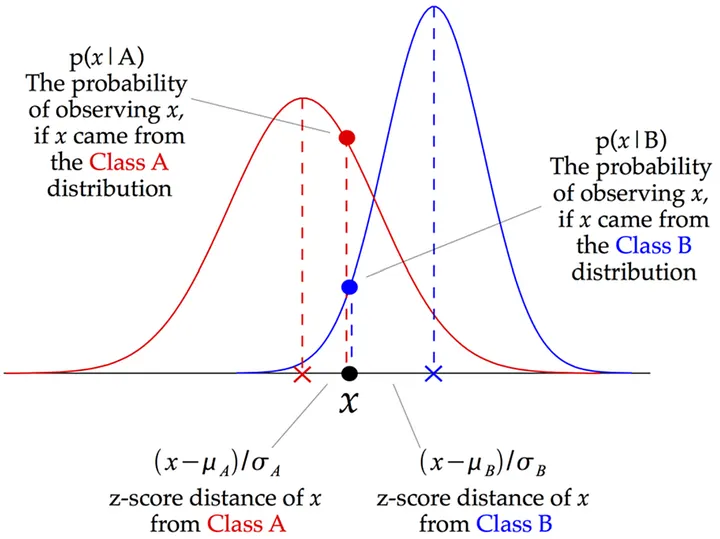

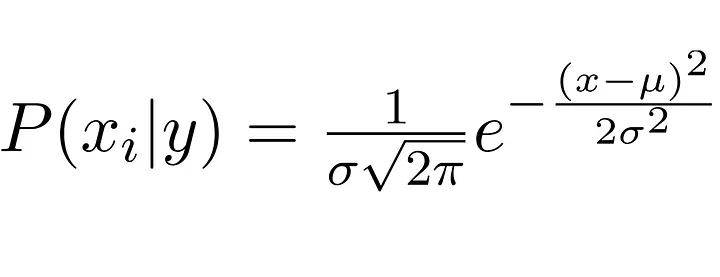

In [12]:
classes = np.unique(y_train)
print(classes)
mean = {}
var = {}
prior = {}

for c in classes:
    X_c = X_train[y_train == c]
    mean[c] = np.mean(X_c, axis=0)
    var[c] = np.var(X_c, axis=0)
    prior[c] = len(X_c) / len(X_train)

y_pred = []

for x in X_test:
    probs = []

    for c in classes:
        prior_log = np.log(prior[c])

        numerator = np.exp(-((x - mean[c]) ** 2) / (2 * var[c]))
        denominator = np.sqrt(2 * np.pi * var[c])
        likelihood = np.sum(np.log(numerator / denominator))

        probs.append(prior_log + likelihood)

    y_pred.append(classes[np.argmax(probs)])

[0 1 2]


In [13]:
y_pred = np.array(y_pred)

accuracy = np.sum(y_test == y_pred) / len(y_test)
print("Accuracy:", accuracy)

Accuracy: 0.9333333333333333


In [27]:
print("\nConfusion Matrix :- \n", confusion_matrix(y_test, y_pred))
print("\nClassification Report :-", classification_report(y_test, y_pred))


Confusion Matrix :- 
 [[ 0  0]
 [ 7 23]]

Classification Report :-               precision    recall  f1-score   support

           1       0.00      0.00      0.00         0
           2       1.00      0.77      0.87        30

    accuracy                           0.77        30
   macro avg       0.50      0.38      0.43        30
weighted avg       1.00      0.77      0.87        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## B. Basic kNN Implementation

**2.** Write a Python program to: a) Load Iris dataset b)Train kNN classifier (k=3) c) Display: Accuracy, Confusion Matrix

In [16]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target

split = int(0.8 * len(df))
train = df[:split]
test = df[split:]
print(train.shape, test.shape)

X_train = train.iloc[:, :-1].values
y_train = train.iloc[:, -1].values
X_test = test.iloc[:, :-1].values
y_test = test.iloc[:, -1].values
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(120, 5) (30, 5)
(120, 4) (120,) (30, 4) (30,)


In [18]:
k_neighbours = int(input())

3


In [42]:
k = k_neighbours
y_pred = []

for test_point in X_test:
    distances = []

    for i in range(len(X_train)):
        dist = np.sqrt(np.sum((test_point - X_train[i])**2))
        distances.append((dist, y_train[i]))

    distances.sort(key=lambda x: x[0])

    neighbors = distances[:k]
    labels = [neighbor[1] for neighbor in neighbors]

    prediction = max(set(labels), key=labels.count)
    y_pred.append(prediction)

In [43]:
y_pred = np.array(y_pred)

accuracy = np.sum(y_test == y_pred) / len(y_test)
print("Accuracy:", accuracy)

Accuracy: 0.7666666666666667


In [44]:
print("\nConfusion Matrix :- \n", confusion_matrix(y_test, y_pred))
print("\nClassification Report :-", classification_report(y_test, y_pred))


Confusion Matrix :- 
 [[ 0  0]
 [ 7 23]]

Classification Report :-               precision    recall  f1-score   support

           1       0.00      0.00      0.00         0
           2       1.00      0.77      0.87        30

    accuracy                           0.77        30
   macro avg       0.50      0.38      0.43        30
weighted avg       1.00      0.77      0.87        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**3.** Write a program to: a) Train kNN for k values from 1 to 20 b)Store accuracy for each k c) Plot graph: X-axis → k value, Y-axis → Accuracy d)
Identify best k

In [45]:
accuracies = []
for k in range(1, 21):
    y_pred = []

    for test_point in X_test:
        distances = []

        for i in range(len(X_train)):
            dist = np.sqrt(np.sum((test_point - X_train[i])**2))
            distances.append((dist, y_train[i]))

        distances.sort(key=lambda x: x[0])
        neighbors = distances[:k]
        labels = [n[1] for n in neighbors]
        prediction = max(set(labels), key=labels.count)
        y_pred.append(prediction)

    y_pred = np.array(y_pred)

    accuracy = np.sum(y_test == y_pred) / len(y_test)
    accuracies.append(accuracy)
    print("For k = ",k , "= ", accuracies[k-1])


For k =  1 =  0.8333333333333334
For k =  2 =  0.7333333333333333
For k =  3 =  0.7666666666666667
For k =  4 =  0.7666666666666667
For k =  5 =  0.8
For k =  6 =  0.7666666666666667
For k =  7 =  0.8
For k =  8 =  0.7666666666666667
For k =  9 =  0.7666666666666667
For k =  10 =  0.7666666666666667
For k =  11 =  0.7666666666666667
For k =  12 =  0.7
For k =  13 =  0.7666666666666667
For k =  14 =  0.7333333333333333
For k =  15 =  0.7333333333333333
For k =  16 =  0.6666666666666666
For k =  17 =  0.6666666666666666
For k =  18 =  0.6666666666666666
For k =  19 =  0.7
For k =  20 =  0.6333333333333333


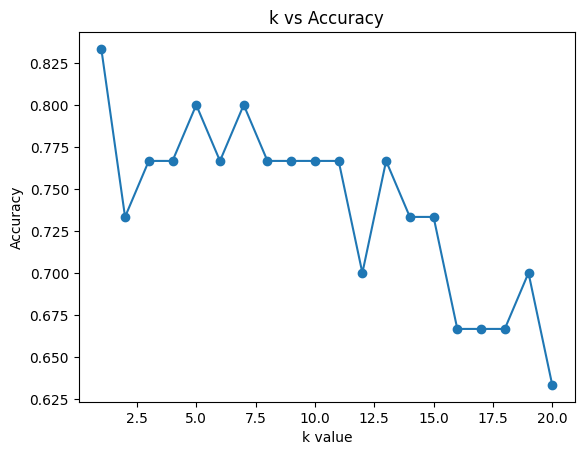

In [39]:
import matplotlib.pyplot as plt
plt.plot(range(1, 21), accuracies, marker='o')
plt.xlabel("k value")
plt.ylabel("Accuracy")
plt.title("k vs Accuracy")
plt.show()

In [40]:
best_k = np.argmax(accuracies) + 1
print("Best k:", best_k)
print("Best Accuracy:", max(accuracies))

Best k: 1
Best Accuracy: 0.8333333333333334


## C. Decision Tree Classification

**4.** Write a program to: a) Load Iris dataset b) Train Decision Tree classifier c) Display: Accuracy, Tree depth, Number of nodes

In [46]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target

split = int(0.8 * len(df))
train = df[:split]
test = df[split:]
print(train.shape, test.shape)

X_train = train.iloc[:, :-1].values
y_train = train.iloc[:, -1].values
X_test = test.iloc[:, :-1].values
y_test = test.iloc[:, -1].values
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(120, 5) (30, 5)
(120, 4) (120,) (30, 4) (30,)


In [47]:
def gini(y):
    classes = np.unique(y)
    g = 1
    for c in classes:
        p = np.sum(y == c) / len(y)
        g -= p**2
    return g

In [48]:
def best_split(X, y):
    best_gini = 1
    best_feature = None
    best_threshold = None

    for feature in range(X.shape[1]):
        thresholds = np.unique(X[:, feature])

        for t in thresholds:
            left = y[X[:, feature] <= t]
            right = y[X[:, feature] > t]

            if len(left) == 0 or len(right) == 0:
                continue

            g = (len(left)/len(y))*gini(left) + \
                (len(right)/len(y))*gini(right)

            if g < best_gini:
                best_gini = g
                best_feature = feature
                best_threshold = t

    return best_feature, best_threshold

In [49]:
def build_tree(X, y, depth=0):
    if len(np.unique(y)) == 1:
        return {"label": y[0], "depth": depth}

    feature, threshold = best_split(X, y)

    if feature is None:
        return {"label": max(set(y), key=list(y).count), "depth": depth}

    left_mask = X[:, feature] <= threshold
    right_mask = X[:, feature] > threshold

    return {
        "feature": feature,
        "threshold": threshold,
        "left": build_tree(X[left_mask], y[left_mask], depth+1),
        "right": build_tree(X[right_mask], y[right_mask], depth+1),
        "depth": depth
    }

In [50]:
def predict_one(tree, x):
    if "label" in tree:
        return tree["label"]

    if x[tree["feature"]] <= tree["threshold"]:
        return predict_one(tree["left"], x)
    else:
        return predict_one(tree["right"], x)

In [53]:
def count_nodes(tree):
    if "label" in tree:
        return 1
    return 1 + count_nodes(tree["left"]) + count_nodes(tree["right"])

In [51]:
def max_depth(tree):
    if "label" in tree:
        return tree["depth"]
    return max(max_depth(tree["left"]), max_depth(tree["right"]))

In [55]:
tree = build_tree(X_train, y_train)
print(tree)
y_pred = np.array([predict_one(tree, x) for x in X_test])

accuracy = np.sum(y_pred == y_test) / len(y_test)

depth = max_depth(tree)
nodes = count_nodes(tree)

print("Accuracy:", accuracy)
print("Tree Depth:", depth)
print("Number of Nodes:", nodes)

{'feature': 2, 'threshold': np.float64(1.9), 'left': {'label': np.int64(0), 'depth': 1}, 'right': {'feature': 2, 'threshold': np.float64(4.9), 'left': {'feature': 0, 'threshold': np.float64(4.9), 'left': {'feature': 1, 'threshold': np.float64(2.4), 'left': {'label': np.int64(1), 'depth': 4}, 'right': {'label': np.int64(2), 'depth': 4}, 'depth': 3}, 'right': {'label': np.int64(1), 'depth': 3}, 'depth': 2}, 'right': {'feature': 3, 'threshold': np.float64(1.7), 'left': {'feature': 1, 'threshold': np.float64(2.2), 'left': {'label': np.int64(2), 'depth': 4}, 'right': {'label': np.int64(1), 'depth': 4}, 'depth': 3}, 'right': {'label': np.int64(2), 'depth': 3}, 'depth': 2}, 'depth': 1}, 'depth': 0}
Accuracy: 0.7333333333333333
Tree Depth: 4
Number of Nodes: 13


**5.** Write Python code to: a) Train Decision Tree b) Visualize the tree using plot_tree c) Display feature names and class names.

Feature Names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Class Names: ['setosa' 'versicolor' 'virginica']


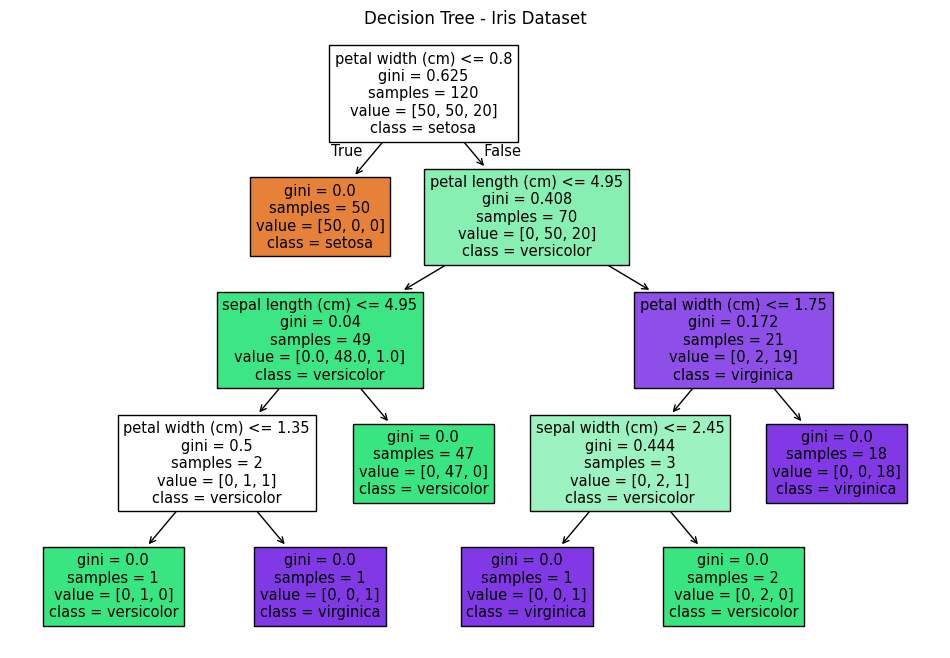

In [59]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

print("Feature Names:", iris.feature_names)
print("Class Names:", iris.target_names)

plt.figure(figsize=(12,8))
plot_tree(model,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True)
plt.title("Decision Tree - Iris Dataset")
plt.show()

**6.** Train two models: a) Decision Tree with criterion='gini' b) Decision Tree with criterion='entropy' c) Compare: Accuracy, Tree depth, Comment on differences

In [64]:
def gini_index(y):
    classes = np.unique(y)
    g = 1.0
    for c in classes:
        p = np.sum(y == c) / len(y)
        g -= p**2
    return g

def entropy_index(y):
    classes = np.unique(y)
    e = 0.0
    for c in classes:
        p = np.sum(y == c) / len(y)
        if p > 0:
            e -= p * np.log2(p)
    return e

def best_split(X, y, criterion="gini"):
    best_score = float("inf")
    best_feature, best_threshold = None, None

    for feature in range(X.shape[1]):
        thresholds = np.unique(X[:, feature])
        for t in thresholds:
            left = y[X[:, feature] <= t]
            right = y[X[:, feature] > t]
            if len(left) == 0 or len(right) == 0:
                continue
            if criterion == "gini":
                score = (len(left)/len(y))*gini_index(left) + (len(right)/len(y))*gini_index(right)
            else:
                score = (len(left)/len(y))*entropy_index(left) + (len(right)/len(y))*entropy_index(right)
            if score < best_score:
                best_score = score
                best_feature = feature
                best_threshold = t
    return best_feature, best_threshold

def build_tree(X, y, criterion="gini", depth=0):
    if len(np.unique(y)) == 1:
        return {"label": y[0], "depth": depth}

    feature, threshold = best_split(X, y, criterion)
    if feature is None:
        return {"label": max(set(y), key=list(y).count), "depth": depth}

    left_mask = X[:, feature] <= threshold
    right_mask = X[:, feature] > threshold
    return {
        "feature": feature,
        "threshold": threshold,
        "left": build_tree(X[left_mask], y[left_mask], criterion, depth+1),
        "right": build_tree(X[right_mask], y[right_mask], criterion, depth+1),
        "depth": depth
    }

def predict_one(tree, x):
    if "label" in tree:
        return tree["label"]
    if x[tree["feature"]] <= tree["threshold"]:
        return predict_one(tree["left"], x)
    else:
        return predict_one(tree["right"], x)

def predict(tree, X):
    return np.array([predict_one(tree, x) for x in X])

def tree_depth(tree):
    if "label" in tree:
        return tree["depth"]
    return max(tree_depth(tree["left"]), tree_depth(tree["right"]))

def count_nodes(tree):
    if "label" in tree:
        return 1
    return 1 + count_nodes(tree["left"]) + count_nodes(tree["right"])

def accuracy(y_true, y_pred):
    return np.sum(y_true == y_pred) / len(y_true)


In [65]:
tree_gini = build_tree(X_train, y_train, criterion="gini")
y_pred_gini = predict(tree_gini, X_test)
acc_gini = accuracy(y_test, y_pred_gini)
depth_gini = tree_depth(tree_gini)
nodes_gini = count_nodes(tree_gini)

In [66]:
tree_entropy = build_tree(X_train, y_train, criterion="entropy")
y_pred_entropy = predict(tree_entropy, X_test)
acc_entropy = accuracy(y_test, y_pred_entropy)
depth_entropy = tree_depth(tree_entropy)
nodes_entropy = count_nodes(tree_entropy)

In [67]:
print("Decision Tree - Gini")
print("Accuracy:", round(acc_gini, 3))
print("Tree Depth:", depth_gini)
print("Number of Nodes:", nodes_gini)
print()

print("Decision Tree - Entropy")
print("Accuracy:", round(acc_entropy, 3))
print("Tree Depth:", depth_entropy)
print("Number of Nodes:", nodes_entropy)
print()

Decision Tree - Gini
Accuracy: 0.733
Tree Depth: 4
Number of Nodes: 13

Decision Tree - Entropy
Accuracy: 0.733
Tree Depth: 4
Number of Nodes: 13



In [68]:
if acc_gini > acc_entropy:
    print("Gini tree is slightly more accurate.")
elif acc_entropy > acc_gini:
    print("Entropy tree is slightly more accurate.")
else:
    print("Both trees have similar accuracy.")

if depth_gini > depth_entropy:
    print("Gini tree is deeper than Entropy tree.")
elif depth_entropy > depth_gini:
    print("Entropy tree is deeper than Gini tree.")
else:
    print("Both trees have similar depth.")


Both trees have similar accuracy.
Both trees have similar depth.
